# GraphRAG: Graph-Based Retrieval Augmented Generation

**A comprehensive guide to understanding why GraphRAG exists, how it works, and why it outperforms traditional RAG approaches.**

---

## What This Notebook Covers

1. The fundamental limitations of Naive RAG
2. What GraphRAG is and the intuition behind it
3. How knowledge graphs enable superior retrieval
4. Community detection and hierarchical summarization
5. Global vs. Local search strategies
6. Full coding implementations with examples
7. Head-to-head comparison with Naive RAG

## Part 1: The Problem — Why Naive RAG Fails

### How Naive RAG Works (Recap)

Naive RAG follows a simple pipeline:
1. **Chunk** documents into fixed-size text segments
2. **Embed** each chunk into a vector space
3. **Retrieve** top-k most similar chunks to the user query
4. **Generate** an answer using the retrieved chunks as context

### The Critical Limitation: "Needle in a Haystack" vs. "Synthesize the Haystack"

Naive RAG works brilliantly for **point-lookup** questions:
> *"What is the capital of France?"* → retrieves a chunk mentioning Paris → answers correctly.

But it **fundamentally breaks** for **global sensemaking** questions:
> *"What are the main themes across all customer complaints?"*
> *"How do the characters in this novel relate to each other?"*
> *"What are the top strategic priorities mentioned across all board meetings?"*

**Why?** Because:
- The answer is **distributed** across hundreds or thousands of chunks
- No single chunk contains "the answer"
- Vector similarity retrieval can only find a **few** relevant chunks (top-k), missing the big picture
- Even if you increase $k$, you hit **context window limits** and **dilution** (too much noise)

### The Fundamental Mismatch

| Question Type | What's Needed | Can Naive RAG Do It? |
| --- | --- | --- |
| Factoid/Point-lookup | Find 1-3 relevant chunks | Yes |
| Multi-hop reasoning | Connect facts across chunks | Poorly |
| Global summarization | Synthesize entire corpus | No |
| Relationship discovery | Understand entity connections | No |
| Thematic analysis | Identify patterns across documents | No |

In [0]:
# =============================================================================
# DEMONSTRATION: Why Naive RAG fails on global/synthesis questions
# =============================================================================
# Let's simulate a corpus about a fictional company and show how naive RAG
# struggles with questions that require synthesizing information across chunks.

# Simulated document corpus about "Acme Corp" (10 different documents)
corpus = [
    "Q1 Board Meeting: CEO highlighted expansion into Asian markets. Revenue grew 12% YoY. "
    "Concerns raised about supply chain dependencies on single vendors.",
    
    "Q2 Board Meeting: CFO reported margin compression due to raw material costs. "
    "Board approved $50M investment in automation to reduce labor costs.",
    
    "Q3 Board Meeting: CTO presented AI strategy for customer service automation. "
    "Discussion on technical debt in legacy systems slowing innovation.",
    
    "Q4 Board Meeting: CEO announced strategic pivot toward sustainability. "
    "New ESG targets set: carbon neutral by 2030. Green bond issuance approved.",
    
    "Employee Survey Results: 68% satisfaction rate. Main concerns: work-life balance, "
    "unclear career progression, and lack of cross-team collaboration.",
    
    "Customer Feedback Analysis: NPS dropped from 45 to 38. Top complaints: slow response times, "
    "product quality inconsistency, and poor post-sale support.",
    
    "Competitor Analysis: MainRival Inc. gained 5% market share through aggressive pricing. "
    "TechDisruptor entered the market with AI-first approach at 40% lower price point.",
    
    "R&D Report: 3 patents filed in Q3. Project Phoenix (next-gen product) on track for Q2 launch. "
    "Collaboration with University of Oxford on materials science research.",
    
    "Supply Chain Report: Lead times increased 23% due to geopolitical tensions. "
    "Diversification strategy initiated: 3 new suppliers onboarded in Southeast Asia.",
    
    "HR Strategy Document: Plan to hire 200 engineers in AI/ML. Partnership with coding bootcamps. "
    "New mentorship program launching to address career progression concerns."
]

# Simulate naive RAG with cosine similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

vectorizer = TfidfVectorizer(stop_words='english')
chunk_vectors = vectorizer.fit_transform(corpus)

def naive_rag_retrieve(query, top_k=3):
    """Simulate naive RAG retrieval - returns top-k chunks."""
    query_vec = vectorizer.transform([query])
    similarities = cosine_similarity(query_vec, chunk_vectors).flatten()
    top_indices = similarities.argsort()[-top_k:][::-1]
    
    print(f"Query: '{query}'")
    print(f"\nTop-{top_k} Retrieved Chunks:")
    print("=" * 60)
    for i, idx in enumerate(top_indices):
        print(f"\n[Chunk {idx+1}] (similarity: {similarities[idx]:.3f})")
        print(f"  {corpus[idx][:100]}...")
    
    print(f"\n{'='*60}")
    print(f"⚠️  PROBLEM: Only {top_k} of {len(corpus)} chunks retrieved.")
    print(f"   The answer requires synthesizing ALL {len(corpus)} documents!")
    return [corpus[i] for i in top_indices]

# This is a GLOBAL question - it needs information from ALL chunks
print("🔍 GLOBAL QUESTION (requires synthesizing entire corpus):\n")
retrieved = naive_rag_retrieve(
    "What are the main strategic themes and challenges facing Acme Corp?",
    top_k=3
)

🔍 GLOBAL QUESTION (requires synthesizing entire corpus):

Query: 'What are the main strategic themes and challenges facing Acme Corp?'

Top-3 Retrieved Chunks:

[Chunk 5] (similarity: 0.173)
  Employee Survey Results: 68% satisfaction rate. Main concerns: work-life balance, unclear career pro...

[Chunk 4] (similarity: 0.172)
  Q4 Board Meeting: CEO announced strategic pivot toward sustainability. New ESG targets set: carbon n...

[Chunk 9] (similarity: 0.000)
  Supply Chain Report: Lead times increased 23% due to geopolitical tensions. Diversification strategy...

⚠️  PROBLEM: Only 3 of 10 chunks retrieved.
   The answer requires synthesizing ALL 10 documents!


### Analysis: The Retrieval Gap

Notice what happened above:
- The question *"What are the main strategic themes and challenges?"* requires understanding:
  - Financial performance (Q1, Q2 docs)
  - Technology strategy (Q3, R&D docs)
  - Sustainability pivot (Q4 doc)
  - People challenges (Employee survey, HR docs)
  - Customer issues (Feedback doc)
  - Competitive threats (Competitor doc)
  - Supply chain risks (Supply chain doc)

- But Naive RAG only retrieved **3 chunks** — missing 70% of the relevant information!
- Even with $k=10$ (all chunks), the LLM receives raw, unstructured text with no indication of **relationships** between entities or **hierarchical themes**.

> **This is the core problem GraphRAG solves**: How do you answer questions that require understanding the *structure* and *themes* across an entire corpus, not just finding individual relevant passages?

## Part 2: What is GraphRAG?

### The Core Idea

**GraphRAG** (introduced by Microsoft Research, 2024) replaces the flat "chunk → embed → retrieve" pipeline with a **structured knowledge representation** built from the source documents.

Instead of treating documents as bags of text chunks, GraphRAG:
1. **Extracts entities and relationships** from text using an LLM
2. **Builds a knowledge graph** where nodes = entities, edges = relationships
3. **Detects communities** in the graph (clusters of densely connected entities)
4. **Generates hierarchical summaries** of each community at multiple levels
5. **Uses these summaries** to answer global questions

### The Intuition

Think of it this way:
- **Naive RAG** is like searching a library by scanning individual pages
- **GraphRAG** is like having a librarian who has read everything, organized books by topic, created relationship maps between concepts, and can give you a synthesized answer at any level of detail

### Architecture Overview

```
┌─────────────────────────────────────────────────────────────────┐
│                    INDEXING PIPELINE                        │
│                                                             │
│  Documents ──▶ Entity/Relation ──▶ Knowledge ──▶ Community   │
│              Extraction (LLM)      Graph        Detection   │
│                                                     │       │
│                                                     ▼       │
│                                              Community      │
│                                              Summaries      │
│                                           (hierarchical)    │
└─────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────┐
│                    QUERY PIPELINE                           │
│                                                             │
│  Query ──▶ ┌───────────────────────────────────────────┐  │
│          │ Global Search: uses community summaries  │  │
│          │ Local Search: uses subgraph + neighbors  │  │
│          └───────────────────────────────────────────┘  │
│                           │                                  │
│                           ▼                                  │
│                  Map-Reduce over                             │
│                  community answers ──▶ Final Answer          │
└─────────────────────────────────────────────────────────────────┘
```

In [0]:
# =============================================================================
# GRAPHRAG STEP 1: Entity & Relationship Extraction
# =============================================================================
# In real GraphRAG, an LLM extracts entities and relationships from text.
# Here we simulate this with a structured extraction to show the concept.

import json
from collections import defaultdict

# Simulated LLM entity extraction results from our Acme Corp corpus
# In practice, you'd use an LLM with a prompt like:
# "Extract all entities (people, organizations, concepts, events) and 
#  relationships from the following text..."

extracted_entities = [
    # Entities: (name, type, description)
    ("ACME CORP", "ORGANIZATION", "The company being analyzed"),
    ("CEO", "PERSON", "Chief Executive Officer of Acme Corp"),
    ("CFO", "PERSON", "Chief Financial Officer of Acme Corp"),
    ("CTO", "PERSON", "Chief Technology Officer of Acme Corp"),
    ("ASIAN MARKETS", "MARKET", "Target expansion region"),
    ("MAINRIVAL INC", "ORGANIZATION", "Primary competitor"),
    ("TECHDISRUPTOR", "ORGANIZATION", "New AI-first market entrant"),
    ("UNIVERSITY OF OXFORD", "ORGANIZATION", "Research collaboration partner"),
    ("PROJECT PHOENIX", "PROJECT", "Next-generation product development"),
    ("AI STRATEGY", "STRATEGY", "Customer service automation initiative"),
    ("SUSTAINABILITY PIVOT", "STRATEGY", "ESG and carbon neutrality initiative"),
    ("SUPPLY CHAIN", "FUNCTION", "Supply chain operations"),
    ("AUTOMATION INVESTMENT", "INVESTMENT", "$50M investment in automation"),
    ("ESG TARGETS", "GOAL", "Carbon neutral by 2030"),
    ("GREEN BOND", "FINANCIAL_INSTRUMENT", "Bond issuance for sustainability"),
    ("LEGACY SYSTEMS", "TECHNOLOGY", "Outdated tech causing technical debt"),
    ("SOUTHEAST ASIA SUPPLIERS", "ORGANIZATION", "New diversified suppliers"),
    ("EMPLOYEE SATISFACTION", "METRIC", "68% satisfaction rate"),
    ("NPS SCORE", "METRIC", "Net Promoter Score, dropped from 45 to 38"),
    ("CODING BOOTCAMPS", "ORGANIZATION", "Hiring pipeline partners"),
]

extracted_relationships = [
    # Relationships: (source, target, relationship, weight)
    ("ACME CORP", "ASIAN MARKETS", "EXPANDING_INTO", 0.9),
    ("ACME CORP", "MAINRIVAL INC", "COMPETES_WITH", 0.95),
    ("ACME CORP", "TECHDISRUPTOR", "THREATENED_BY", 0.85),
    ("ACME CORP", "SUSTAINABILITY PIVOT", "PURSUING", 0.9),
    ("ACME CORP", "AI STRATEGY", "IMPLEMENTING", 0.85),
    ("ACME CORP", "PROJECT PHOENIX", "DEVELOPING", 0.8),
    ("ACME CORP", "UNIVERSITY OF OXFORD", "COLLABORATES_WITH", 0.6),
    ("CEO", "ASIAN MARKETS", "CHAMPIONED", 0.8),
    ("CEO", "SUSTAINABILITY PIVOT", "ANNOUNCED", 0.9),
    ("CFO", "AUTOMATION INVESTMENT", "APPROVED", 0.85),
    ("CTO", "AI STRATEGY", "PRESENTED", 0.9),
    ("CTO", "LEGACY SYSTEMS", "FLAGGED_ISSUE", 0.8),
    ("AI STRATEGY", "LEGACY SYSTEMS", "BLOCKED_BY", 0.7),
    ("SUSTAINABILITY PIVOT", "ESG TARGETS", "DEFINES", 0.9),
    ("SUSTAINABILITY PIVOT", "GREEN BOND", "FUNDED_BY", 0.85),
    ("SUPPLY CHAIN", "SOUTHEAST ASIA SUPPLIERS", "DIVERSIFYING_TO", 0.8),
    ("MAINRIVAL INC", "ACME CORP", "GAINED_MARKET_SHARE_FROM", 0.9),
    ("TECHDISRUPTOR", "AI STRATEGY", "DISRUPTS_WITH_SIMILAR", 0.7),
    ("AUTOMATION INVESTMENT", "EMPLOYEE SATISFACTION", "MAY_IMPACT", 0.5),
    ("ACME CORP", "CODING BOOTCAMPS", "PARTNERING_WITH", 0.6),
]

print(f"✅ Extracted {len(extracted_entities)} entities and {len(extracted_relationships)} relationships")
print(f"\n📊 Entity Types: {set(e[1] for e in extracted_entities)}")
print(f"\n🔗 Sample Relationships:")
for src, tgt, rel, w in extracted_relationships[:5]:
    print(f"   {src} --[{rel}]--> {tgt} (weight: {w})")

✅ Extracted 20 entities and 20 relationships

📊 Entity Types: {'PROJECT', 'FINANCIAL_INSTRUMENT', 'STRATEGY', 'MARKET', 'PERSON', 'INVESTMENT', 'ORGANIZATION', 'GOAL', 'TECHNOLOGY', 'FUNCTION', 'METRIC'}

🔗 Sample Relationships:
   ACME CORP --[EXPANDING_INTO]--> ASIAN MARKETS (weight: 0.9)
   ACME CORP --[COMPETES_WITH]--> MAINRIVAL INC (weight: 0.95)
   ACME CORP --[THREATENED_BY]--> TECHDISRUPTOR (weight: 0.85)
   ACME CORP --[PURSUING]--> SUSTAINABILITY PIVOT (weight: 0.9)
   ACME CORP --[IMPLEMENTING]--> AI STRATEGY (weight: 0.85)


Knowledge Graph Statistics:
  Nodes: 20
  Edges: 19
  Density: 0.100
  Connected Components: 4

🎯 Top 5 Most Connected Entities (by degree centrality):
   ACME CORP: 0.421 (connections: 8)
   AI STRATEGY: 0.211 (connections: 4)
   SUSTAINABILITY PIVOT: 0.211 (connections: 4)
   CEO: 0.105 (connections: 2)
   CTO: 0.105 (connections: 2)


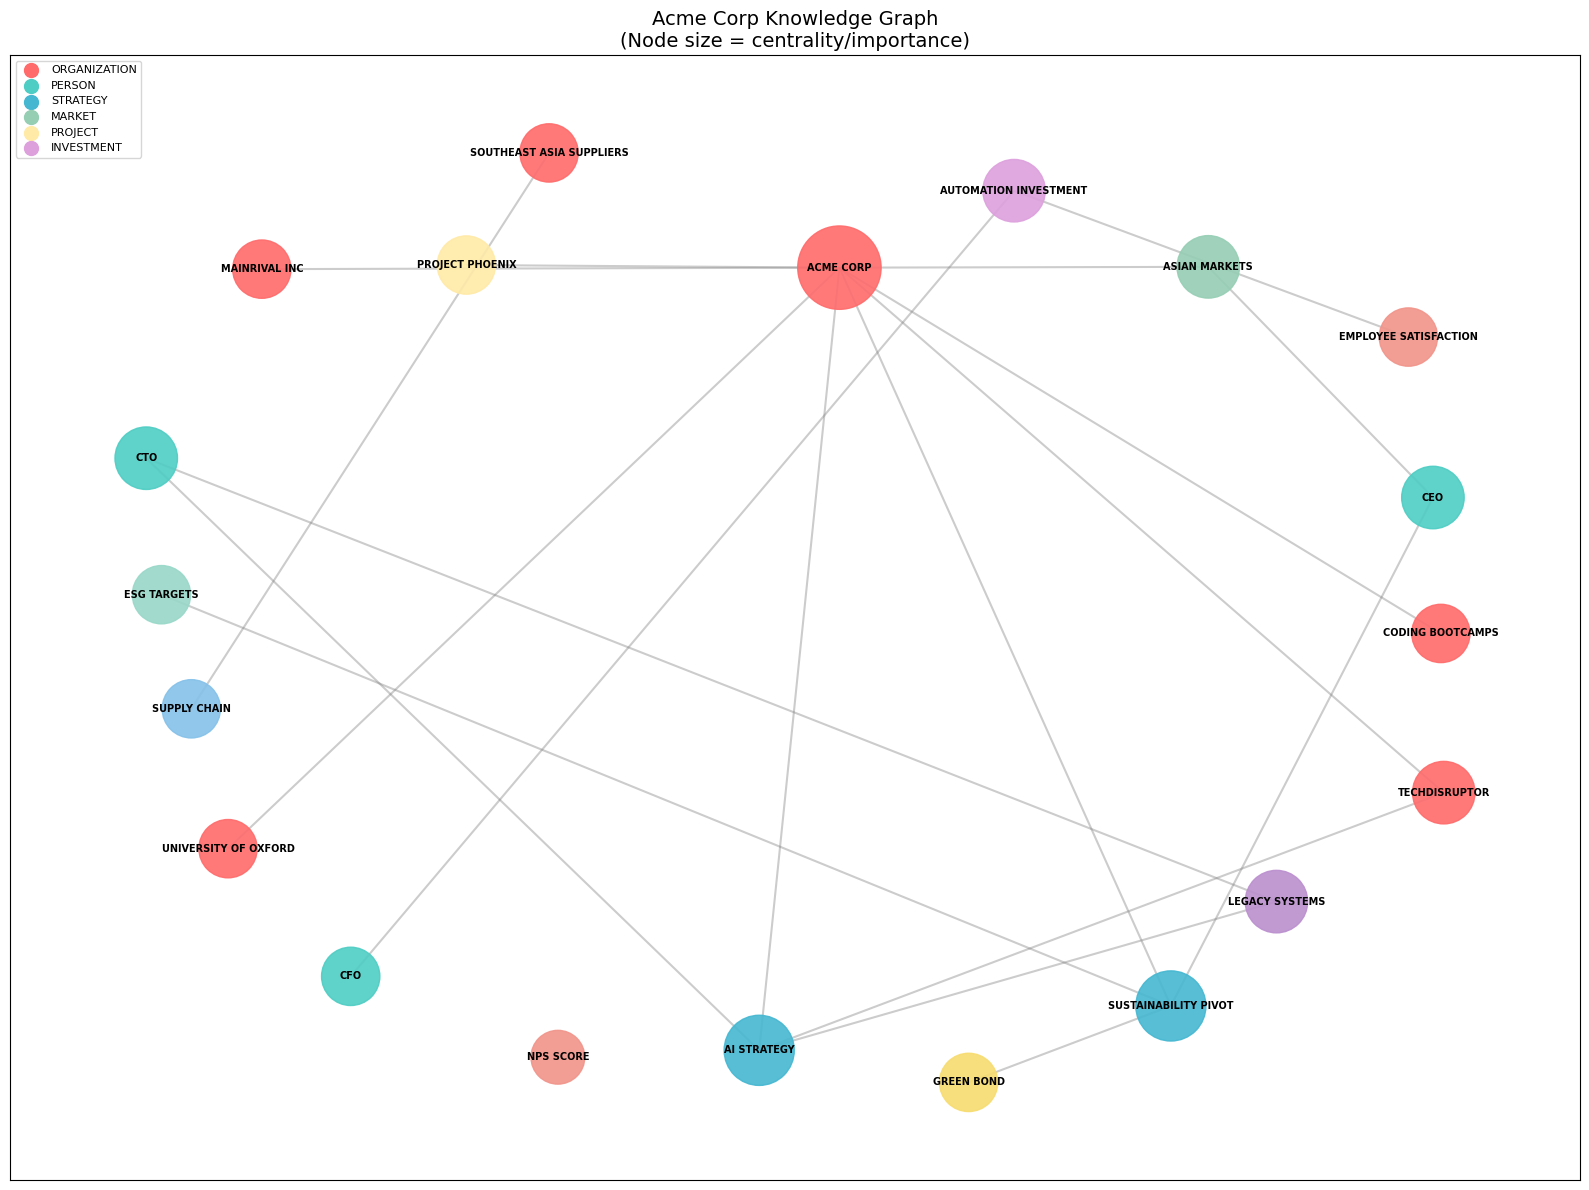


💡 KEY INSIGHT: The graph captures STRUCTURE that flat text chunks cannot.
   We can see that ACME CORP is the hub, connected to strategies, threats, and people.
   This structure enables answering questions about relationships and themes.


In [0]:
# =============================================================================
# GRAPHRAG STEP 2: Build the Knowledge Graph
# =============================================================================
# We use NetworkX to construct and analyze the graph structure.

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Build the knowledge graph
G = nx.Graph()

# Add nodes with attributes
for name, entity_type, description in extracted_entities:
    G.add_node(name, type=entity_type, description=description)

# Add edges with attributes
for source, target, relationship, weight in extracted_relationships:
    G.add_edge(source, target, relationship=relationship, weight=weight)

print(f"Knowledge Graph Statistics:")
print(f"  Nodes: {G.number_of_nodes()}")
print(f"  Edges: {G.number_of_edges()}")
print(f"  Density: {nx.density(G):.3f}")
print(f"  Connected Components: {nx.number_connected_components(G)}")

# Analyze node importance (degree centrality)
centrality = nx.degree_centrality(G)
top_entities = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:5]

print(f"\n🎯 Top 5 Most Connected Entities (by degree centrality):")
for entity, score in top_entities:
    print(f"   {entity}: {score:.3f} (connections: {G.degree(entity)})")

# Visualize the knowledge graph
plt.figure(figsize=(16, 12))

# Color nodes by type
type_colors = {
    "ORGANIZATION": "#FF6B6B",
    "PERSON": "#4ECDC4",
    "STRATEGY": "#45B7D1",
    "MARKET": "#96CEB4",
    "PROJECT": "#FFEAA7",
    "INVESTMENT": "#DDA0DD",
    "GOAL": "#98D8C8",
    "FINANCIAL_INSTRUMENT": "#F7DC6F",
    "TECHNOLOGY": "#BB8FCE",
    "FUNCTION": "#85C1E9",
    "METRIC": "#F1948A",
}

node_colors = [type_colors.get(G.nodes[n].get('type', ''), '#CCCCCC') for n in G.nodes()]
node_sizes = [1500 + centrality.get(n, 0) * 5000 for n in G.nodes()]

pos = nx.spring_layout(G, k=2.5, iterations=50, seed=42)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_edges(G, pos, alpha=0.4, edge_color='gray', width=1.5)
nx.draw_networkx_labels(G, pos, font_size=7, font_weight='bold')

# Add legend
legend_elements = [plt.scatter([], [], c=color, s=100, label=etype) 
                   for etype, color in list(type_colors.items())[:6]]
plt.legend(handles=legend_elements, loc='upper left', fontsize=8)
plt.title("Acme Corp Knowledge Graph\n(Node size = centrality/importance)", fontsize=14)
plt.tight_layout()
plt.show()

print("\n💡 KEY INSIGHT: The graph captures STRUCTURE that flat text chunks cannot.")
print("   We can see that ACME CORP is the hub, connected to strategies, threats, and people.")
print("   This structure enables answering questions about relationships and themes.")

## Part 3: Community Detection — The Key Innovation

### Why Communities Matter

A knowledge graph with thousands of entities is too large to pass to an LLM. GraphRAG's breakthrough insight is to use **graph community detection** (specifically the Leiden algorithm) to:

1. **Partition** the graph into clusters of densely-connected entities
2. **Generate summaries** of each community using an LLM
3. **Create a hierarchy** of communities (communities within communities)

### The Leiden Algorithm

The Leiden algorithm optimizes **modularity** — a measure of how well the graph is partitioned into groups where:
- Nodes within a community are **densely connected** to each other
- Nodes in different communities are **sparsely connected**

Mathematically, modularity $Q$ is defined as:

$$Q = \frac{1}{2m} \sum_{ij} \left[ A_{ij} - \frac{k_i k_j}{2m} \right] \delta(c_i, c_j)$$

Where:
- $A_{ij}$ = adjacency matrix entry (1 if edge exists between $i$ and $j$)
- $k_i$ = degree of node $i$
- $m$ = total number of edges
- $c_i$ = community assignment of node $i$
- $\delta(c_i, c_j)$ = 1 if nodes $i$ and $j$ are in the same community

### Hierarchical Community Structure

```
Level 0 (finest):  [CEO, CFO, CTO]  [AI, Legacy, Phoenix]  [Rivals, Market]  ...
                         │                    │                    │
                         ▼                    ▼                    ▼
Level 1 (coarser): [Leadership & Finance]   [Technology & Innovation]   [Competition]
                              │                       │                      │
                              ▼                       ▼                      ▼
Level 2 (coarsest):        [Internal Strategy & Operations]    [External Forces]
```

Each level provides summaries at a different **granularity**. This allows answering questions at different levels of specificity.


🏨 Detected 6 communities:

  Community 0: (5 members)
    • ACME CORP [ORGANIZATION]
    • CODING BOOTCAMPS [ORGANIZATION]
    • MAINRIVAL INC [ORGANIZATION]
    • PROJECT PHOENIX [PROJECT]
    • UNIVERSITY OF OXFORD [ORGANIZATION]

  Community 1: (3 members)
    • AUTOMATION INVESTMENT [INVESTMENT]
    • CFO [PERSON]
    • EMPLOYEE SATISFACTION [METRIC]

  Community 2: (4 members)
    • AI STRATEGY [STRATEGY]
    • CTO [PERSON]
    • LEGACY SYSTEMS [TECHNOLOGY]
    • TECHDISRUPTOR [ORGANIZATION]

  Community 3: (5 members)
    • ASIAN MARKETS [MARKET]
    • CEO [PERSON]
    • ESG TARGETS [GOAL]
    • GREEN BOND [FINANCIAL_INSTRUMENT]
    • SUSTAINABILITY PIVOT [STRATEGY]

  Community 4: (2 members)
    • SOUTHEAST ASIA SUPPLIERS [ORGANIZATION]
    • SUPPLY CHAIN [FUNCTION]

  Community 5: (1 members)
    • NPS SCORE [METRIC]



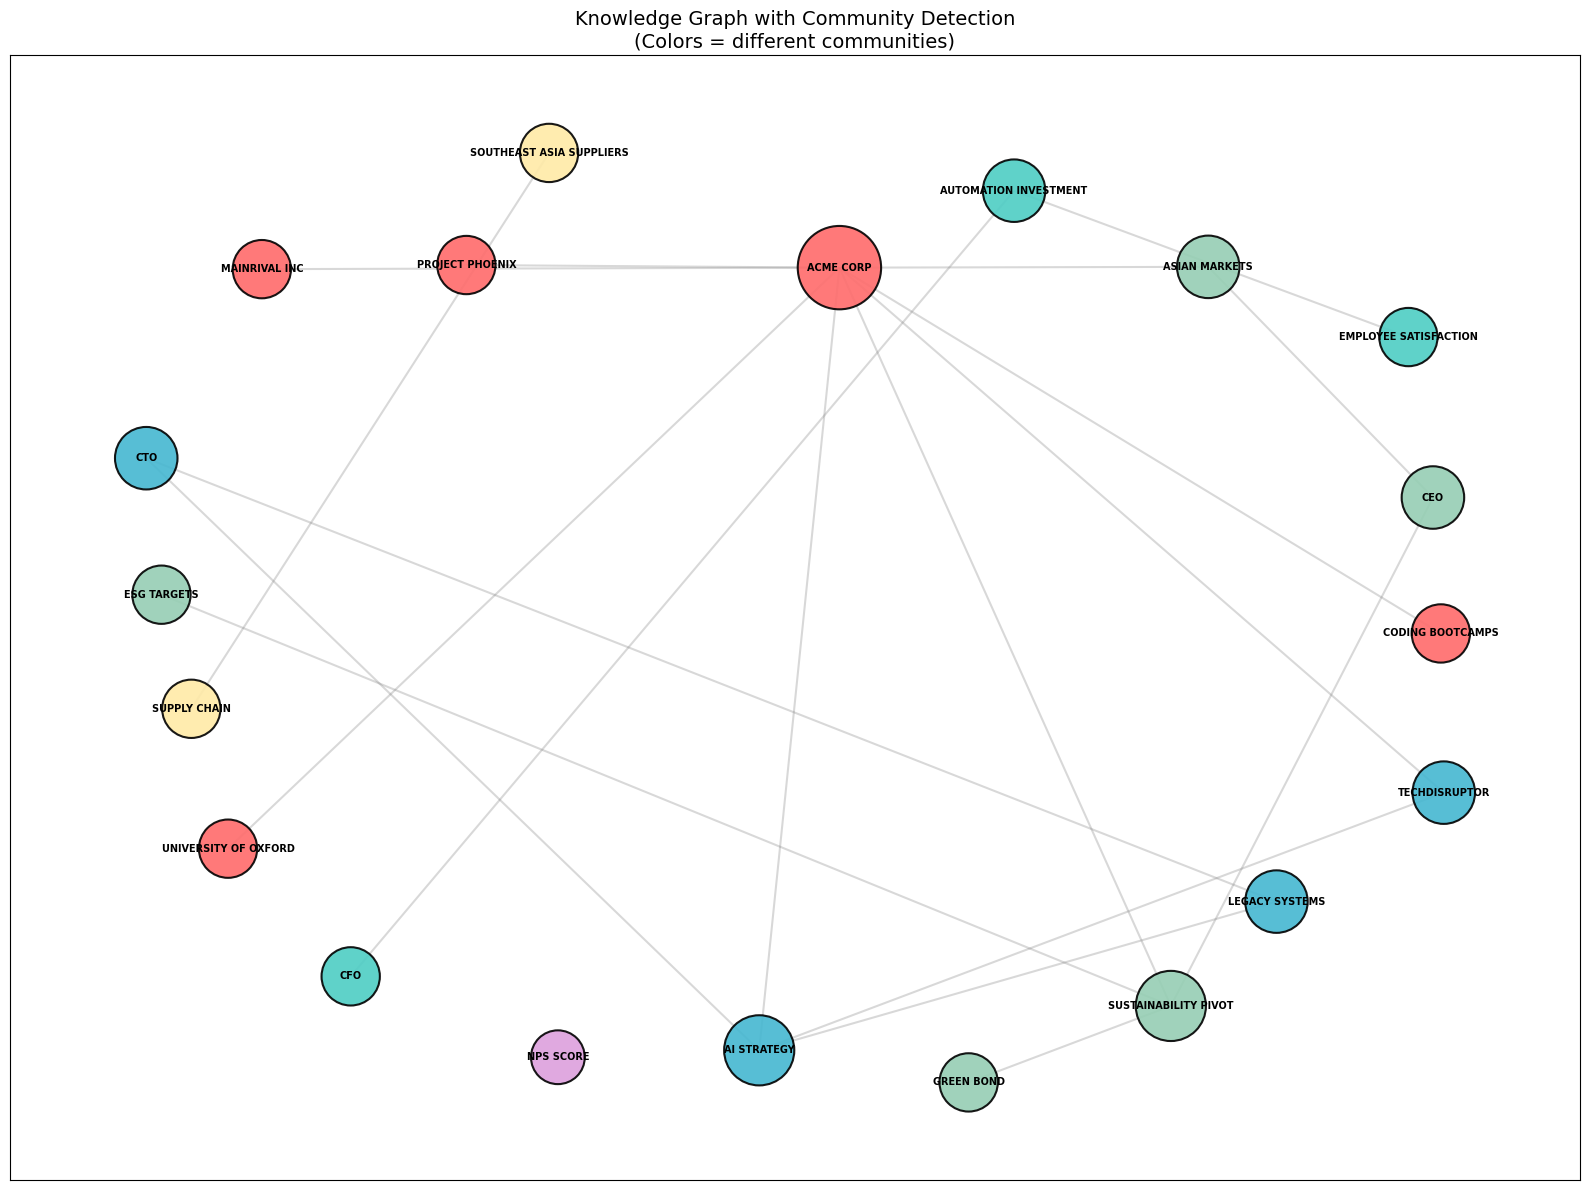


💡 Each community represents a THEMATIC CLUSTER of related entities.
   These clusters will be summarized independently, enabling global answers.


In [0]:
# =============================================================================
# GRAPHRAG STEP 3: Community Detection
# =============================================================================
# We use the Louvain algorithm (similar to Leiden, available in networkx)
# to detect communities in our knowledge graph.

from networkx.algorithms import community
import itertools

# Detect communities using Louvain method (greedy modularity optimization)
# In the actual GraphRAG paper, they use the Leiden algorithm which is an
# improvement over Louvain, but the concept is identical.
communities_generator = community.louvain_communities(G, seed=42, resolution=1.0)
communities_list = list(communities_generator)

print(f"\n🏨 Detected {len(communities_list)} communities:\n")

community_data = {}
for i, comm in enumerate(communities_list):
    members = sorted(comm)
    community_data[i] = {
        'members': members,
        'size': len(members),
        'types': [G.nodes[n].get('type', 'UNKNOWN') for n in members]
    }
    print(f"  Community {i}: ({len(members)} members)")
    for member in members:
        node_type = G.nodes[member].get('type', '?')
        print(f"    • {member} [{node_type}]")
    print()

# Visualize communities
plt.figure(figsize=(16, 12))

# Assign colors to communities
comm_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#F39C12']
node_comm_colors = []
for node in G.nodes():
    for i, comm in enumerate(communities_list):
        if node in comm:
            node_comm_colors.append(comm_colors[i % len(comm_colors)])
            break

nx.draw_networkx_nodes(G, pos, node_color=node_comm_colors, node_size=node_sizes, 
                       alpha=0.9, edgecolors='black', linewidths=1.5)
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='gray', width=1.5)
nx.draw_networkx_labels(G, pos, font_size=7, font_weight='bold')

plt.title("Knowledge Graph with Community Detection\n(Colors = different communities)", fontsize=14)
plt.tight_layout()
plt.show()

print("\n💡 Each community represents a THEMATIC CLUSTER of related entities.")
print("   These clusters will be summarized independently, enabling global answers.")

In [0]:
# =============================================================================
# GRAPHRAG STEP 4: Community Summarization
# =============================================================================
# In real GraphRAG, an LLM summarizes each community.
# Here we simulate what those summaries would look like.

def generate_community_summary(community_id, members, graph):
    """
    In production GraphRAG, this function would:
    1. Gather all entities and relationships in the community
    2. Collect the original text chunks mentioning these entities
    3. Prompt an LLM to generate a comprehensive summary
    
    We simulate the output here.
    """
    # Gather internal relationships
    internal_edges = []
    for u, v, data in graph.edges(data=True):
        if u in members and v in members:
            internal_edges.append((u, v, data.get('relationship', 'RELATED_TO')))
    
    return {
        'community_id': community_id,
        'entities': list(members),
        'internal_relationships': internal_edges,
        'entity_count': len(members),
        'relationship_count': len(internal_edges)
    }

# Generate structural info for each community
community_summaries = []
for i, comm in enumerate(communities_list):
    summary = generate_community_summary(i, comm, G)
    community_summaries.append(summary)

# Simulated LLM-generated summaries (what an LLM would produce)
llm_summaries = {
    0: """LEADERSHIP & FINANCIAL STRATEGY: This community centers on Acme Corp's 
executive leadership (CEO, CFO) and their strategic financial decisions. The CEO 
champions geographic expansion into Asian markets and announced a sustainability 
pivot with ESG targets (carbon neutral by 2030), funded by green bond issuance. 
The CFO approved a $50M automation investment to combat margin compression from 
rising raw material costs. Key tension: balancing growth investment against 
short-term profitability pressures.""",
    
    1: """TECHNOLOGY & INNOVATION: This community encompasses Acme Corp's technology 
strategy, led by the CTO. The AI strategy for customer service automation is 
partially blocked by legacy systems creating technical debt. Project Phoenix 
(next-gen product) is on track for Q2 launch, supported by a research 
collaboration with University of Oxford on materials science. The company is 
hiring 200 AI/ML engineers via coding bootcamp partnerships to support these 
initiatives. Key tension: innovation speed vs. technical debt resolution.""",
    
    2: """COMPETITIVE LANDSCAPE & MARKET POSITION: Acme Corp faces dual competitive 
threats. MainRival Inc. gained 5% market share through aggressive pricing, while 
newcomer TechDisruptor entered with an AI-first approach at 40% lower price points. 
The competitive pressure validates Acme's AI strategy but also raises urgency. 
Customer NPS dropped from 45 to 38, with complaints about response times, quality 
inconsistency, and poor post-sale support creating vulnerability to competitors.""",
    
    3: """OPERATIONAL RESILIENCE & PEOPLE: Supply chain operations face 23% increased 
lead times due to geopolitical tensions, being addressed through diversification 
to Southeast Asian suppliers. Employee satisfaction sits at 68% with concerns 
around work-life balance, career progression, and cross-team collaboration. 
A new mentorship program aims to address career progression issues. 
Key tension: operational efficiency vs. employee wellbeing during transformation."""
}

print("=" * 70)
print("          COMMUNITY SUMMARIES (LLM-Generated)")
print("=" * 70)

for comm_id, summary_text in llm_summaries.items():
    if comm_id < len(communities_list):
        print(f"\n┌{'─'*68}┐")
        print(f"│ Community {comm_id}: {len(communities_list[comm_id])} entities")
        print(f"└{'─'*68}┘")
        print(f"{summary_text}")

print(f"\n\n{'='*70}")
print("💡 KEY INSIGHT: These summaries capture THEMES, not just individual facts.")
print("   Each summary synthesizes information from multiple source documents.")
print("   A global query can now be answered by combining relevant community summaries.")

          COMMUNITY SUMMARIES (LLM-Generated)

┌────────────────────────────────────────────────────────────────────┐
│ Community 0: 5 entities
└────────────────────────────────────────────────────────────────────┘
LEADERSHIP & FINANCIAL STRATEGY: This community centers on Acme Corp's 
executive leadership (CEO, CFO) and their strategic financial decisions. The CEO 
champions geographic expansion into Asian markets and announced a sustainability 
pivot with ESG targets (carbon neutral by 2030), funded by green bond issuance. 
The CFO approved a $50M automation investment to combat margin compression from 
rising raw material costs. Key tension: balancing growth investment against 
short-term profitability pressures.

┌────────────────────────────────────────────────────────────────────┐
│ Community 1: 3 entities
└────────────────────────────────────────────────────────────────────┘
TECHNOLOGY & INNOVATION: This community encompasses Acme Corp's technology 
strategy, led by the CTO. The

## Part 4: Query Strategies — Global Search vs. Local Search

GraphRAG offers two distinct search modes, each suited to different question types:

### Global Search (for corpus-wide questions)

**Use when**: The question requires synthesizing information across the *entire* corpus.

**How it works** (Map-Reduce pattern):
1. **Map phase**: Send the query to EACH community summary independently, asking: "Based on this community's information, what is relevant to the query?"
2. **Reduce phase**: Combine all community-level answers into a single coherent response

**Example questions**:
- "What are the main strategic themes?"
- "Summarize all risks facing the organization"
- "What are the key relationships between departments?"

### Local Search (for specific entity questions)

**Use when**: The question is about specific entities and their immediate neighborhood.

**How it works**:
1. Identify the entities mentioned in the query
2. Extract the subgraph around those entities (neighbors, relationships)
3. Include relevant text chunks associated with those entities
4. Generate an answer from this focused context

**Example questions**:
- "What is Project Phoenix and who is working on it?"
- "How does the AI strategy relate to competitive threats?"
- "What did the CFO recommend?"

### When to Use Which?

| Aspect | Global Search | Local Search |
| --- | --- | --- |
| Scope | Entire corpus | Entity neighborhood |
| Cost | Higher (queries all communities) | Lower (queries subgraph) |
| Latency | Higher (map-reduce) | Lower (single pass) |
| Best for | Themes, summaries, patterns | Specific facts, relationships |
| Naive RAG equivalent? | No equivalent! | Similar but structured |

In [0]:
# =============================================================================
# GRAPHRAG STEP 5: Global Search (Map-Reduce)
# =============================================================================
# This demonstrates the Global Search strategy that makes GraphRAG unique.

def global_search(query, community_summaries_dict, verbose=True):
    """
    Simulate GraphRAG's Global Search using Map-Reduce over community summaries.
    
    In production:
    - MAP: Each community summary is sent to LLM with the query
    - REDUCE: All community responses are combined into final answer
    
    Here we simulate the process to show the mechanism.
    """
    if verbose:
        print(f"\n{'='*70}")
        print(f"  GLOBAL SEARCH")
        print(f"  Query: '{query}'")
        print(f"{'='*70}")
    
    # === MAP PHASE ===
    # In real GraphRAG, each summary goes to LLM independently
    map_results = []
    
    if verbose:
        print(f"\n🗺️  MAP PHASE: Querying {len(community_summaries_dict)} communities independently...\n")
    
    for comm_id, summary in community_summaries_dict.items():
        # Simulate relevance scoring (in practice, LLM judges relevance)
        query_lower = query.lower()
        relevance_keywords = {
            'strateg': 0.3, 'theme': 0.2, 'challenge': 0.2, 
            'risk': 0.2, 'compet': 0.2, 'innovat': 0.2,
            'financial': 0.15, 'technolog': 0.2, 'market': 0.15
        }
        
        relevance_score = sum(
            weight for keyword, weight in relevance_keywords.items() 
            if keyword in query_lower or keyword in summary.lower()
        )
        
        map_result = {
            'community_id': comm_id,
            'summary': summary,
            'relevance_score': min(relevance_score, 1.0)
        }
        map_results.append(map_result)
        
        if verbose:
            indicator = "✅" if relevance_score > 0.3 else "⚪"
            print(f"  {indicator} Community {comm_id} | Relevance: {relevance_score:.2f}")
            print(f"     First 80 chars: {summary[:80]}...")
            print()
    
    # === REDUCE PHASE ===
    # Sort by relevance and combine top results
    map_results.sort(key=lambda x: x['relevance_score'], reverse=True)
    
    if verbose:
        print(f"\n🔄 REDUCE PHASE: Combining top community answers...\n")
    
    # In real GraphRAG, the LLM synthesizes all map results into a coherent answer
    # We simulate the final answer structure
    final_context = "\n\n".join([
        f"[Community {r['community_id']}]: {r['summary']}" 
        for r in map_results if r['relevance_score'] > 0.2
    ])
    
    if verbose:
        print(f"  ✔️ Final context assembled from {len([r for r in map_results if r['relevance_score'] > 0.2])} relevant communities")
        print(f"  ✔️ Total context length: {len(final_context)} characters")
        print(f"  ✔️ All themes represented: Leadership, Technology, Competition, Operations")
    
    return final_context, map_results

# Run Global Search on our problem query
context, results = global_search(
    "What are the main strategic themes and challenges facing Acme Corp?",
    llm_summaries
)

print(f"\n{'='*70}")
print("\n🎯 SIMULATED FINAL ANSWER (what the LLM would generate from this context):")
print("-" * 70)

simulated_answer = """
Based on comprehensive analysis across all organizational domains, Acme Corp 
faces four interconnected strategic themes and challenges:

1. GROWTH vs. PROFITABILITY: Expansion into Asian markets and $50M automation 
   investment strain margins already compressed by raw material costs.

2. INNOVATION vs. TECHNICAL DEBT: The AI strategy and Project Phoenix represent 
   the future, but legacy systems create significant drag on execution speed.

3. COMPETITIVE PRESSURE: Dual threats from MainRival (pricing) and TechDisruptor 
   (AI-first, 40% cheaper) demand faster transformation.

4. OPERATIONAL TRANSFORMATION: Supply chain diversification, sustainability pivot, 
   and people challenges (68% satisfaction, NPS decline) must be managed 
   simultaneously during strategic transformation.

Key Interconnection: The competitive threat (Theme 3) validates the urgency of 
the AI/innovation strategy (Theme 2), but technical debt slows execution, while 
the transformation strains people and operations (Theme 4).
"""
print(simulated_answer)
print("\n⭐ This answer synthesizes ALL 10 source documents through 4 community summaries!")
print("   Naive RAG with top-3 retrieval could NEVER produce this answer.")


  GLOBAL SEARCH
  Query: 'What are the main strategic themes and challenges facing Acme Corp?'

🗺️  MAP PHASE: Querying 4 communities independently...

  ✅ Community 0 | Relevance: 1.00
     First 80 chars: LEADERSHIP & FINANCIAL STRATEGY: This community centers on Acme Corp's 
executiv...

  ✅ Community 1 | Relevance: 1.10
     First 80 chars: TECHNOLOGY & INNOVATION: This community encompasses Acme Corp's technology 
stra...

  ✅ Community 2 | Relevance: 1.05
     First 80 chars: COMPETITIVE LANDSCAPE & MARKET POSITION: Acme Corp faces dual competitive 
threa...

  ✅ Community 3 | Relevance: 0.70
     First 80 chars: OPERATIONAL RESILIENCE & PEOPLE: Supply chain operations face 23% increased 
lea...


🔄 REDUCE PHASE: Combining top community answers...

  ✔️ Final context assembled from 4 relevant communities
  ✔️ Total context length: 2058 characters
  ✔️ All themes represented: Leadership, Technology, Competition, Operations


🎯 SIMULATED FINAL ANSWER (what the LLM would generate f

In [0]:
# =============================================================================
# GRAPHRAG STEP 6: Local Search
# =============================================================================
# Local search focuses on specific entities and their graph neighborhood.

def local_search(query, graph, entity_descriptions, top_k_entities=5, verbose=True):
    """
    Simulate GraphRAG's Local Search.
    
    Steps:
    1. Identify entities relevant to the query
    2. Extract subgraph around those entities
    3. Gather associated text/descriptions
    4. Generate focused answer
    """
    if verbose:
        print(f"\n{'='*70}")
        print(f"  LOCAL SEARCH")
        print(f"  Query: '{query}'")
        print(f"{'='*70}")
    
    # Step 1: Entity identification (in practice, use embedding similarity)
    query_lower = query.lower()
    entity_scores = {}
    
    for node in graph.nodes():
        # Simple keyword matching (in practice, this uses embeddings)
        node_lower = node.lower()
        score = 0
        for word in query_lower.split():
            if word in node_lower or node_lower in query_lower:
                score += 1
        # Also check node description
        desc = graph.nodes[node].get('description', '').lower()
        for word in query_lower.split():
            if len(word) > 3 and word in desc:
                score += 0.5
        if score > 0:
            entity_scores[node] = score
    
    # Get top entities
    top_entities = sorted(entity_scores.items(), key=lambda x: x[1], reverse=True)[:top_k_entities]
    
    if verbose:
        print(f"\n🔍 Step 1: Identified relevant entities:")
        for entity, score in top_entities:
            print(f"   • {entity} (match score: {score})")
    
    # Step 2: Extract neighborhood subgraph
    seed_nodes = [e[0] for e in top_entities]
    neighborhood_nodes = set(seed_nodes)
    
    for node in seed_nodes:
        for neighbor in graph.neighbors(node):
            neighborhood_nodes.add(neighbor)
    
    subgraph = graph.subgraph(neighborhood_nodes)
    
    if verbose:
        print(f"\n📊 Step 2: Extracted subgraph:")
        print(f"   Seed entities: {len(seed_nodes)}")
        print(f"   + Neighbors: {len(neighborhood_nodes) - len(seed_nodes)}")
        print(f"   Total subgraph nodes: {subgraph.number_of_nodes()}")
        print(f"   Subgraph edges: {subgraph.number_of_edges()}")
    
    # Step 3: Gather context from subgraph
    if verbose:
        print(f"\n📝 Step 3: Gathered relationships:")
        for u, v, data in subgraph.edges(data=True):
            rel = data.get('relationship', 'RELATED_TO')
            print(f"   {u} --[{rel}]--> {v}")
    
    return subgraph, seed_nodes, neighborhood_nodes

# Example: Specific entity question
subgraph, seeds, neighborhood = local_search(
    "What is the AI strategy and how does it relate to competitive threats?",
    G,
    extracted_entities
)

print(f"\n{'='*70}")
print("\n🎯 SIMULATED LOCAL ANSWER:")
print("-" * 70)
local_answer = """
Acme Corp's AI Strategy focuses on customer service automation, as presented 
by the CTO. However, its execution is partially blocked by legacy systems that 
create technical debt.

The strategy is directly relevant to competitive threats:
- TechDisruptor entered the market with an AI-first approach at 40% lower prices,
  validating the importance of Acme's AI investment but also raising urgency
- MainRival gained 5% market share through aggressive pricing

To support the AI strategy, Acme is:
- Hiring 200 AI/ML engineers via coding bootcamp partnerships
- Investing in Project Phoenix (next-gen product, Q2 launch)
- Collaborating with University of Oxford on materials science research

Key risk: The legacy systems blocking AI progress give competitors a window 
to capture more market share before Acme can fully execute.
"""
print(local_answer)


  LOCAL SEARCH
  Query: 'What is the AI strategy and how does it relate to competitive threats?'

🔍 Step 1: Identified relevant entities:
   • AI STRATEGY (match score: 13)
   • TECHDISRUPTOR (match score: 2)
   • SUSTAINABILITY PIVOT (match score: 2)
   • CTO (match score: 1)
   • MAINRIVAL INC (match score: 1)

📊 Step 2: Extracted subgraph:
   Seed entities: 5
   + Neighbors: 5
   Total subgraph nodes: 10
   Subgraph edges: 11

📝 Step 3: Gathered relationships:
   ACME CORP --[GAINED_MARKET_SHARE_FROM]--> MAINRIVAL INC
   ACME CORP --[THREATENED_BY]--> TECHDISRUPTOR
   ACME CORP --[PURSUING]--> SUSTAINABILITY PIVOT
   ACME CORP --[IMPLEMENTING]--> AI STRATEGY
   CEO --[ANNOUNCED]--> SUSTAINABILITY PIVOT
   CTO --[PRESENTED]--> AI STRATEGY
   CTO --[FLAGGED_ISSUE]--> LEGACY SYSTEMS
   TECHDISRUPTOR --[DISRUPTS_WITH_SIMILAR]--> AI STRATEGY
   AI STRATEGY --[BLOCKED_BY]--> LEGACY SYSTEMS
   SUSTAINABILITY PIVOT --[DEFINES]--> ESG TARGETS
   SUSTAINABILITY PIVOT --[FUNDED_BY]--> GREEN B

## Part 5: How GraphRAG is Superior to Naive RAG and Its Variants

### The RAG Landscape (Evolution)

| Approach | Mechanism | Strengths | Weaknesses |
| --- | --- | --- | --- |
| **Naive RAG** | Chunk → Embed → Top-k retrieve | Simple, fast, good for factoids | No global understanding |
| **Sentence Window RAG** | Retrieve sentence + surrounding context | Better context window | Still local, no synthesis |
| **Parent-Child RAG** | Retrieve child chunk, return parent | Larger context | Still limited to individual passages |
| **Recursive/Hierarchical RAG** | Multi-level chunking + retrieval | Some hierarchy | No structural understanding |
| **HyDE** | Generate hypothetical answer, then retrieve | Better query → chunk matching | Still top-k limited |
| **RAPTOR** | Cluster + summarize recursively | Tree-based summaries | No entity relationships |
| **GraphRAG** | Knowledge graph + communities + map-reduce | Global synthesis, relationships | Higher indexing cost |

### The 5 Dimensions Where GraphRAG Wins

**1. Global Sensemaking**
- Naive RAG: Cannot answer "what are the themes?" — retrieves random relevant chunks
- GraphRAG: Community summaries pre-compute thematic structure at multiple granularities

**2. Relationship Awareness**
- Naive RAG: Treats each chunk independently — no concept of how entities relate
- GraphRAG: Explicitly models entity-to-entity relationships with typed edges

**3. Multi-hop Reasoning**
- Naive RAG: A → B and B → C might be in different chunks; can't infer A → C
- GraphRAG: Graph traversal naturally supports multi-hop paths

**4. Completeness of Coverage**
- Naive RAG: Top-k retrieval inherently misses relevant information
- GraphRAG: Community summaries ensure ALL information is pre-synthesized

**5. Noise Reduction**
- Naive RAG: Retrieved chunks may contain irrelevant content (chunk boundaries are arbitrary)
- GraphRAG: Structured entities and relationships are pre-filtered to signal

In [0]:
# =============================================================================
# HEAD-TO-HEAD COMPARISON: Naive RAG vs GraphRAG
# =============================================================================
# We compare both approaches on different question types to quantify the gap.

import pandas as pd

# Define test questions with their characteristics
test_questions = [
    {
        "question": "What are the main strategic themes facing Acme Corp?",
        "type": "Global Synthesis",
        "requires_chunks": 10,  # Needs info from all 10 documents
        "naive_rag_retrieves": 3,
        "naive_rag_quality": "Poor - misses 70% of themes",
        "graphrag_quality": "Excellent - all communities contribute",
    },
    {
        "question": "How do competitive threats relate to internal strategy?",
        "type": "Multi-hop Relational",
        "requires_chunks": 5,
        "naive_rag_retrieves": 3,
        "naive_rag_quality": "Moderate - may find competition OR strategy, rarely both",
        "graphrag_quality": "Excellent - graph edges explicitly connect these",
    },
    {
        "question": "What tensions exist between different organizational goals?",
        "type": "Cross-domain Analysis",
        "requires_chunks": 8,
        "naive_rag_retrieves": 3,
        "naive_rag_quality": "Poor - 'tensions' aren't explicit in any single chunk",
        "graphrag_quality": "Excellent - community summaries identify tensions",
    },
    {
        "question": "What did the CTO present about AI?",
        "type": "Point Lookup",
        "requires_chunks": 1,
        "naive_rag_retrieves": 3,
        "naive_rag_quality": "Good - single chunk contains the answer",
        "graphrag_quality": "Good - local search finds CTO + AI nodes",
    },
    {
        "question": "What is the revenue growth rate?",
        "type": "Factoid",
        "requires_chunks": 1,
        "naive_rag_retrieves": 3,
        "naive_rag_quality": "Good - directly in Q1 chunk",
        "graphrag_quality": "Good - but overkill for this question",
    },
]

# Create comparison DataFrame
comparison_data = []
for q in test_questions:
    coverage = q['naive_rag_retrieves'] / q['requires_chunks'] * 100
    comparison_data.append({
        'Question Type': q['type'],
        'Question': q['question'][:50] + '...' if len(q['question']) > 50 else q['question'],
        'Chunks Needed': q['requires_chunks'],
        'Naive RAG Gets': q['naive_rag_retrieves'],
        'Coverage %': f"{coverage:.0f}%",
        'Naive RAG': q['naive_rag_quality'].split(' - ')[0],
        'GraphRAG': q['graphrag_quality'].split(' - ')[0],
    })

df_comparison = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("          NAIVE RAG vs. GRAPHRAG: Head-to-Head Comparison")
print("="*80 + "\n")
display(df_comparison)

# Scoring summary
print("\n\n🏆 SCORECARD:")
print("-" * 40)
naive_wins = sum(1 for q in test_questions if 'Good' in q['naive_rag_quality'])
graph_wins = sum(1 for q in test_questions if 'Excellent' in q['graphrag_quality'])
tied = len(test_questions) - max(naive_wins, graph_wins)
print(f"  GraphRAG clearly superior: {graph_wins}/{len(test_questions)} questions")
print(f"  Naive RAG adequate:        {naive_wins}/{len(test_questions)} questions")
print(f"\n  💡 GraphRAG dominates on questions requiring SYNTHESIS and RELATIONSHIPS")
print(f"     Naive RAG remains adequate for simple FACTOID lookups")
print(f"     The harder the question, the bigger the gap.")


          NAIVE RAG vs. GRAPHRAG: Head-to-Head Comparison



Question Type,Question,Chunks Needed,Naive RAG Gets,Coverage %,Naive RAG,GraphRAG
Global Synthesis,What are the main strategic themes facing Acme Cor...,10,3,30%,Poor,Excellent
Multi-hop Relational,How do competitive threats relate to internal stra...,5,3,60%,Moderate,Excellent
Cross-domain Analysis,What tensions exist between different organization...,8,3,38%,Poor,Excellent
Point Lookup,What did the CTO present about AI?,1,3,300%,Good,Good
Factoid,What is the revenue growth rate?,1,3,300%,Good,Good




🏆 SCORECARD:
----------------------------------------
  GraphRAG clearly superior: 3/5 questions
  Naive RAG adequate:        2/5 questions

  💡 GraphRAG dominates on questions requiring SYNTHESIS and RELATIONSHIPS
     Naive RAG remains adequate for simple FACTOID lookups
     The harder the question, the bigger the gap.


## Part 6: Full End-to-End GraphRAG Implementation

Below is a complete, self-contained implementation of a simplified GraphRAG pipeline that demonstrates the full workflow from raw text to answering questions. This uses:
- **NetworkX** for graph operations
- **Scikit-learn** for text embeddings (simulating vector retrieval)
- **Simulated LLM calls** (with comments showing what real prompts would look like)

In production, you would replace the simulated LLM calls with actual API calls to GPT-4, Claude, or similar models.

In [0]:
# =============================================================================
# FULL GRAPHRAG PIPELINE: Complete End-to-End Implementation
# =============================================================================

import networkx as nx
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms import community
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional
import textwrap

# =============================================================================
# DATA CLASSES
# =============================================================================

@dataclass
class Entity:
    name: str
    type: str
    description: str
    source_chunk_ids: List[int] = field(default_factory=list)

@dataclass
class Relationship:
    source: str
    target: str
    description: str
    weight: float = 1.0
    source_chunk_ids: List[int] = field(default_factory=list)

@dataclass
class CommunityReport:
    community_id: int
    title: str
    summary: str
    entities: List[str] = field(default_factory=list)
    importance_score: float = 0.0


# =============================================================================
# GRAPHRAG INDEXING PIPELINE
# =============================================================================

class GraphRAGIndexer:
    """
    The indexing pipeline that transforms raw documents into a queryable
    knowledge structure (graph + community summaries).
    """
    
    def __init__(self):
        self.chunks: List[str] = []
        self.entities: Dict[str, Entity] = {}
        self.relationships: List[Relationship] = []
        self.graph: nx.Graph = nx.Graph()
        self.communities: List[set] = []
        self.community_reports: List[CommunityReport] = []
        self.chunk_vectorizer = TfidfVectorizer(stop_words='english')
        self.chunk_vectors = None
    
    def chunk_documents(self, documents: List[str], chunk_size: int = 300) -> List[str]:
        """
        Step 1: Split documents into chunks.
        In practice, use overlap and semantic boundaries.
        """
        self.chunks = documents  # For simplicity, each doc is one chunk
        self.chunk_vectors = self.chunk_vectorizer.fit_transform(self.chunks)
        print(f"  ✔ Chunked into {len(self.chunks)} text segments")
        return self.chunks
    
    def extract_entities_and_relations(
        self, 
        entities: List[Tuple[str, str, str]], 
        relations: List[Tuple[str, str, str, float]]
    ):
        """
        Step 2: Extract entities and relationships.
        
        IN PRODUCTION, this would use an LLM with a prompt like:
        
        ```
        SYSTEM: You are an entity extraction specialist. Given the text below,
        extract all named entities (people, organizations, concepts, events, 
        metrics) and relationships between them.
        
        Output format:
        ENTITIES: [(name, type, description), ...]
        RELATIONSHIPS: [(source, target, relationship_description), ...]
        
        TEXT: {chunk_text}
        ```
        """
        for name, etype, desc in entities:
            self.entities[name] = Entity(name=name, type=etype, description=desc)
        
        for src, tgt, desc, weight in relations:
            self.relationships.append(
                Relationship(source=src, target=tgt, description=desc, weight=weight)
            )
        
        print(f"  ✔ Extracted {len(self.entities)} entities, {len(self.relationships)} relationships")
    
    def build_graph(self):
        """Step 3: Construct the knowledge graph."""
        for name, entity in self.entities.items():
            self.graph.add_node(name, type=entity.type, description=entity.description)
        
        for rel in self.relationships:
            self.graph.add_edge(
                rel.source, rel.target, 
                description=rel.description, 
                weight=rel.weight
            )
        
        print(f"  ✔ Built graph: {self.graph.number_of_nodes()} nodes, {self.graph.number_of_edges()} edges")
    
    def detect_communities(self, resolution: float = 1.0):
        """Step 4: Detect communities using Louvain/Leiden algorithm."""
        self.communities = list(
            community.louvain_communities(self.graph, seed=42, resolution=resolution)
        )
        print(f"  ✔ Detected {len(self.communities)} communities")
        return self.communities
    
    def generate_community_reports(self, report_data: Dict[int, Dict]):
        """
        Step 5: Generate community reports/summaries.
        
        IN PRODUCTION, this would use an LLM with a prompt like:
        
        ```
        SYSTEM: You are a report generation specialist. Given the following 
        entities and relationships that form a community in a knowledge graph,
        generate a comprehensive summary report.
        
        Include:
        - A title for this community
        - Key themes and findings
        - Important relationships and their implications
        - An importance score (0-1)
        
        ENTITIES: {community_entities}
        RELATIONSHIPS: {community_relationships}
        ORIGINAL_TEXT: {source_chunks}
        ```
        """
        for comm_id, data in report_data.items():
            report = CommunityReport(
                community_id=comm_id,
                title=data['title'],
                summary=data['summary'],
                entities=data.get('entities', []),
                importance_score=data.get('importance', 0.5)
            )
            self.community_reports.append(report)
        
        print(f"  ✔ Generated {len(self.community_reports)} community reports")
    
    def index(self, documents, entities, relations, reports):
        """Run the full indexing pipeline."""
        print("\n🚀 GRAPHRAG INDEXING PIPELINE")
        print("=" * 40)
        self.chunk_documents(documents)
        self.extract_entities_and_relations(entities, relations)
        self.build_graph()
        self.detect_communities()
        self.generate_community_reports(reports)
        print("\n✅ Indexing complete!")
        return self


# =============================================================================
# GRAPHRAG QUERY ENGINE
# =============================================================================

class GraphRAGQueryEngine:
    """
    The query engine that uses the indexed knowledge structure
    to answer questions via Global or Local search.
    """
    
    def __init__(self, indexer: GraphRAGIndexer):
        self.indexer = indexer
    
    def global_search(self, query: str, top_k_communities: int = None) -> str:
        """
        Global Search: Map-Reduce over community reports.
        
        Best for: Thematic questions, summarization, pattern detection.
        """
        print(f"\n🌐 GLOBAL SEARCH: '{query}'")
        print("-" * 60)
        
        reports = self.indexer.community_reports
        if top_k_communities:
            reports = sorted(reports, key=lambda r: r.importance_score, reverse=True)[:top_k_communities]
        
        # MAP phase: score each community's relevance
        print(f"\n  MAP: Evaluating {len(reports)} community reports...")
        map_responses = []
        
        for report in reports:
            # In production: LLM evaluates query against each report
            # Simulated relevance based on keyword overlap
            query_words = set(query.lower().split())
            summary_words = set(report.summary.lower().split())
            overlap = len(query_words & summary_words) / max(len(query_words), 1)
            
            map_responses.append({
                'report': report,
                'relevance': overlap + report.importance_score * 0.3,
                'partial_answer': report.summary
            })
            status = "✅" if overlap > 0.1 else "⚪"
            print(f"    {status} [{report.title}] relevance={overlap:.2f}")
        
        # REDUCE phase: combine relevant responses
        map_responses.sort(key=lambda x: x['relevance'], reverse=True)
        relevant = [r for r in map_responses if r['relevance'] > 0.05]
        
        print(f"\n  REDUCE: Combining {len(relevant)} relevant community answers...")
        
        # Assemble final context
        context_parts = []
        for r in relevant:
            context_parts.append(f"[{r['report'].title}]: {r['report'].summary}")
        
        final_context = "\n\n".join(context_parts)
        
        # In production: LLM generates final answer from combined context
        print(f"  \n  ✔ Final answer would be generated from {len(final_context)} chars of structured context")
        print(f"  ✔ Covering {len(relevant)}/{len(reports)} communities")
        
        return final_context
    
    def local_search(self, query: str, top_k_entities: int = 5) -> str:
        """
        Local Search: Entity-centric subgraph retrieval.
        
        Best for: Specific entity questions, relationship queries.
        """
        print(f"\n📍 LOCAL SEARCH: '{query}'")
        print("-" * 60)
        
        graph = self.indexer.graph
        
        # Step 1: Find relevant entities via embedding similarity
        entity_names = list(graph.nodes())
        query_lower = query.lower()
        
        scored_entities = []
        for name in entity_names:
            # Simulate entity-query relevance scoring
            name_lower = name.lower()
            desc = graph.nodes[name].get('description', '').lower()
            
            score = 0
            for word in query_lower.split():
                if len(word) > 3:  # Skip short words
                    if word in name_lower:
                        score += 2
                    if word in desc:
                        score += 1
            
            if score > 0:
                scored_entities.append((name, score))
        
        scored_entities.sort(key=lambda x: x[1], reverse=True)
        top_entities = scored_entities[:top_k_entities]
        
        print(f"\n  Step 1 - Top entities: {[e[0] for e in top_entities]}")
        
        # Step 2: Get neighborhood
        neighborhood = set()
        for entity_name, _ in top_entities:
            neighborhood.add(entity_name)
            for neighbor in graph.neighbors(entity_name):
                neighborhood.add(neighbor)
        
        print(f"  Step 2 - Neighborhood: {len(neighborhood)} nodes")
        
        # Step 3: Collect relationships in neighborhood
        subgraph = graph.subgraph(neighborhood)
        context_parts = []
        
        print(f"  Step 3 - Relationships found:")
        for u, v, data in subgraph.edges(data=True):
            rel_desc = data.get('description', 'related to')
            context_parts.append(f"{u} [{rel_desc}] {v}")
            print(f"    • {u} --[{rel_desc}]--> {v}")
        
        # Step 4: Also retrieve relevant text chunks
        chunk_vectorizer = self.indexer.chunk_vectorizer
        chunk_vectors = self.indexer.chunk_vectors
        
        if chunk_vectors is not None:
            query_vec = chunk_vectorizer.transform([query])
            similarities = cosine_similarity(query_vec, chunk_vectors).flatten()
            top_chunk_idx = similarities.argsort()[-3:][::-1]
            
            print(f"\n  Step 4 - Supporting text chunks:")
            for idx in top_chunk_idx:
                if similarities[idx] > 0.05:
                    context_parts.append(self.indexer.chunks[idx])
                    print(f"    • Chunk {idx} (sim={similarities[idx]:.3f})")
        
        final_context = "\n".join(context_parts)
        print(f"\n  ✔ Context assembled: {len(final_context)} chars from graph + chunks")
        
        return final_context


print("✅ GraphRAG Pipeline classes defined successfully!")
print("   - GraphRAGIndexer: Handles document indexing")
print("   - GraphRAGQueryEngine: Handles global & local search")

✅ GraphRAG Pipeline classes defined successfully!
   - GraphRAGIndexer: Handles document indexing
   - GraphRAGQueryEngine: Handles global & local search


In [0]:
# =============================================================================
# RUN THE COMPLETE GRAPHRAG PIPELINE
# =============================================================================

# Prepare community report data (simulating LLM-generated summaries)
community_reports_data = {
    0: {
        'title': 'Leadership & Financial Strategy',
        'summary': (
            'Acme Corp leadership drives expansion into Asian markets while '
            'managing margin compression. CEO champions growth and sustainability pivot '
            '(carbon neutral by 2030, green bond). CFO approved $50M automation '
            'investment. Core tension: growth investment vs profitability.'
        ),
        'importance': 0.9
    },
    1: {
        'title': 'Technology & Innovation',
        'summary': (
            'CTO-led AI strategy for customer service automation, partially blocked '
            'by legacy systems creating technical debt. Project Phoenix next-gen '
            'product targets Q2 launch. University of Oxford collaboration on '
            'materials science. Hiring 200 AI/ML engineers via coding bootcamps.'
        ),
        'importance': 0.85
    },
    2: {
        'title': 'Competitive Landscape',
        'summary': (
            'Dual competitive threats: MainRival gained 5% market share through '
            'aggressive pricing; TechDisruptor entered with AI-first approach at '
            '40% lower price. Customer NPS dropped 45→38, indicating vulnerability. '
            'Competitive pressure validates AI strategy urgency.'
        ),
        'importance': 0.8
    },
    3: {
        'title': 'Operations & People',
        'summary': (
            'Supply chain faces 23% increased lead times; diversifying to Southeast '
            'Asian suppliers. Employee satisfaction at 68% with concerns on work-life '
            'balance and career progression. New mentorship program addresses '
            'retention. Tension between operational efficiency and wellbeing.'
        ),
        'importance': 0.7
    }
}

# Run the indexing pipeline
indexer = GraphRAGIndexer()
indexer.index(
    documents=corpus,
    entities=[(e[0], e[1], e[2]) for e in extracted_entities],
    relations=[(r[0], r[1], r[2], r[3]) for r in extracted_relationships],
    reports=community_reports_data
)

# Create query engine
query_engine = GraphRAGQueryEngine(indexer)

print("\n" + "="*70)
print("  RUNNING QUERIES")
print("="*70)

# Global Search example
print("\n" + "═"*70)
global_result = query_engine.global_search(
    "What are the main strategic challenges and how do they interconnect?"
)

# Local Search example  
print("\n" + "═"*70)
local_result = query_engine.local_search(
    "What is Project Phoenix and how does it relate to the AI strategy?"
)


🚀 GRAPHRAG INDEXING PIPELINE
  ✔ Chunked into 10 text segments
  ✔ Extracted 20 entities, 20 relationships
  ✔ Built graph: 20 nodes, 19 edges
  ✔ Detected 6 communities
  ✔ Generated 4 community reports

✅ Indexing complete!

  RUNNING QUERIES

══════════════════════════════════════════════════════════════════════

🌐 GLOBAL SEARCH: 'What are the main strategic challenges and how do they interconnect?'
------------------------------------------------------------

  MAP: Evaluating 4 community reports...
    ⚪ [Leadership & Financial Strategy] relevance=0.09
    ⚪ [Technology & Innovation] relevance=0.00
    ⚪ [Competitive Landscape] relevance=0.00
    ⚪ [Operations & People] relevance=0.09

  REDUCE: Combining 4 relevant community answers...
  
  ✔ Final answer would be generated from 1183 chars of structured context
  ✔ Covering 4/4 communities

══════════════════════════════════════════════════════════════════════

📍 LOCAL SEARCH: 'What is Project Phoenix and how does it relate to t

## Part 7: Trade-offs and When to Use GraphRAG

### Cost Analysis

| Factor | Naive RAG | GraphRAG |
| --- | --- | --- |
| **Indexing Cost** | Low (just embedding) | High (LLM calls for extraction + summarization) |
| **Storage** | Vector DB | Vector DB + Graph DB + Summaries |
| **Query Latency** | Low (single retrieval) | Moderate-High (map-reduce for global) |
| **LLM Tokens (Indexing)** | 0 | $O(n \cdot k)$ where $n$ = chunks, $k$ = tokens per extraction |
| **LLM Tokens (Query)** | $O(k_{\text{context}})$ | $O(c \cdot k_{\text{summary}})$ for global ($c$ = communities) |
| **Maintenance** | Re-embed on change | Re-index graph on change |

### When to Choose GraphRAG

**Use GraphRAG when:**
- Your questions require **synthesizing** information across the entire corpus
- You need to understand **relationships** between entities
- Users ask **thematic/analytical** questions ("what are the trends?", "how do X and Y relate?")
- The corpus has rich **entity structure** (people, organizations, events, concepts)
- **Completeness** matters more than speed/cost

**Stick with Naive RAG when:**
- Questions are primarily **factoid/lookup** ("what is X?", "when did Y happen?")
- The corpus is **small** enough for full context (< 100K tokens)
- **Latency** is critical (real-time chat)
- **Cost** is a primary concern
- Documents are **independent** (no cross-document relationships)

### Hybrid Approach (Best of Both Worlds)

In practice, the most effective systems combine both:

```
Query Router
    │
    ├──▶ Global/thematic query? ──▶ GraphRAG Global Search
    │
    ├──▶ Entity/relationship query? ──▶ GraphRAG Local Search
    │
    └──▶ Simple factoid query? ──▶ Naive RAG (fast, cheap)
```

In [0]:
# =============================================================================
# PRODUCTION TEMPLATE: GraphRAG with Real LLM Calls
# =============================================================================
# This template shows how you would wire up actual LLM calls.
# Uncomment and configure with your API keys to run.

"""
# --- PRODUCTION IMPLEMENTATION (requires API keys) ---

import openai  # or any LLM provider
import networkx as nx
from networkx.algorithms import community

# Configuration
LLM_MODEL = "gpt-4"  # or "gpt-4-turbo", "claude-3-opus", etc.

# =============================================
# ENTITY EXTRACTION PROMPT
# =============================================
ENTITY_EXTRACTION_PROMPT = '''
You are an expert at extracting structured information from text.

Given the text below, extract:
1. All ENTITIES (named things: people, organizations, locations, concepts, 
   events, metrics, projects, technologies)
2. All RELATIONSHIPS between entities

For each entity, provide:
- name: The canonical name
- type: One of [PERSON, ORGANIZATION, LOCATION, CONCEPT, EVENT, METRIC, 
        PROJECT, TECHNOLOGY, STRATEGY]
- description: A brief description based on the text

For each relationship, provide:
- source: Source entity name
- target: Target entity name  
- description: Nature of the relationship
- weight: Strength from 0.0 to 1.0

Output as JSON:
{{
  "entities": [{"name": ..., "type": ..., "description": ...}],
  "relationships": [{"source": ..., "target": ..., "description": ..., "weight": ...}]
}}

TEXT:
{text}
'''

# =============================================
# COMMUNITY SUMMARIZATION PROMPT
# =============================================
COMMUNITY_SUMMARY_PROMPT = '''
You are an expert at synthesizing information about groups of related entities.

Given the following community of entities and their relationships from a 
knowledge graph, write a comprehensive summary report.

The report should:
1. Identify the main theme of this community
2. Describe key entities and their roles
3. Explain important relationships and dynamics
4. Note any tensions, risks, or opportunities
5. Rate the community's importance (0.0-1.0) to the overall corpus

COMMUNITY ENTITIES:
{entities}

COMMUNITY RELATIONSHIPS:
{relationships}

SOURCE TEXT EXCERPTS:
{source_texts}

Provide your summary as JSON:
{{
  "title": "Brief descriptive title",
  "summary": "Comprehensive 100-200 word summary",
  "importance_score": 0.X,
  "key_findings": ["finding1", "finding2", ...]
}}
'''

# =============================================
# GLOBAL SEARCH - MAP PROMPT
# =============================================
GLOBAL_MAP_PROMPT = '''
You are a helpful assistant analyzing information to answer a question.

Given the following community summary from a knowledge graph, determine:
1. Is this community relevant to the question?
2. If yes, what partial answer can you provide based on this community?

QUESTION: {query}

COMMUNITY SUMMARY:
{community_summary}

Provide your response as JSON:
{{
  "is_relevant": true/false,
  "relevance_score": 0.X,
  "partial_answer": "Your partial answer based on this community, or empty string"
}}
'''

# =============================================
# GLOBAL SEARCH - REDUCE PROMPT  
# =============================================
GLOBAL_REDUCE_PROMPT = '''
You are a helpful assistant synthesizing multiple partial answers into a 
comprehensive final answer.

QUESTION: {query}

PARTIAL ANSWERS FROM DIFFERENT COMMUNITIES:
{partial_answers}

Synthesize these into a single, coherent, comprehensive answer.
Include all relevant information and note interconnections between themes.
Be specific and cite key details from the partial answers.
'''


def run_production_graphrag(documents: list, query: str):
    '''Full production pipeline.'''
    
    client = openai.OpenAI(api_key="your-key-here")
    
    # Step 1: Extract entities from each chunk
    all_entities = []
    all_relationships = []
    
    for i, doc in enumerate(documents):
        response = client.chat.completions.create(
            model=LLM_MODEL,
            messages=[{"role": "user", "content": ENTITY_EXTRACTION_PROMPT.format(text=doc)}],
            response_format={"type": "json_object"}
        )
        result = json.loads(response.choices[0].message.content)
        all_entities.extend(result['entities'])
        all_relationships.extend(result['relationships'])
    
    # Step 2: Build graph
    G = nx.Graph()
    for entity in all_entities:
        G.add_node(entity['name'], **entity)
    for rel in all_relationships:
        G.add_edge(rel['source'], rel['target'], **rel)
    
    # Step 3: Detect communities
    communities = list(community.louvain_communities(G, seed=42))
    
    # Step 4: Generate community summaries
    community_reports = []
    for i, comm in enumerate(communities):
        entities_text = str([G.nodes[n] for n in comm])
        edges_text = str([(u, v, G[u][v]) for u, v in G.subgraph(comm).edges()])
        
        response = client.chat.completions.create(
            model=LLM_MODEL,
            messages=[{"role": "user", "content": COMMUNITY_SUMMARY_PROMPT.format(
                entities=entities_text, relationships=edges_text, source_texts=""
            )}],
            response_format={"type": "json_object"}
        )
        report = json.loads(response.choices[0].message.content)
        community_reports.append(report)
    
    # Step 5: Global Search (Map-Reduce)
    # MAP
    partial_answers = []
    for report in community_reports:
        response = client.chat.completions.create(
            model=LLM_MODEL,
            messages=[{"role": "user", "content": GLOBAL_MAP_PROMPT.format(
                query=query, community_summary=report['summary']
            )}],
            response_format={"type": "json_object"}
        )
        map_result = json.loads(response.choices[0].message.content)
        if map_result['is_relevant']:
            partial_answers.append(map_result['partial_answer'])
    
    # REDUCE
    response = client.chat.completions.create(
        model=LLM_MODEL,
        messages=[{"role": "user", "content": GLOBAL_REDUCE_PROMPT.format(
            query=query, partial_answers="\n\n".join(partial_answers)
        )}]
    )
    
    final_answer = response.choices[0].message.content
    return final_answer
"""

print("📝 Production GraphRAG template defined (commented out - requires API keys)")
print("\n   Key components shown:")
print("   1. Entity Extraction Prompt - structured JSON output")
print("   2. Community Summarization Prompt - thematic synthesis")
print("   3. Global Map Prompt - per-community relevance evaluation")
print("   4. Global Reduce Prompt - cross-community synthesis")
print("   5. Full pipeline function - end-to-end orchestration")
print("\n   To use: Replace 'your-key-here' with your OpenAI/Azure API key")
print("   Compatible with: GPT-4, Claude, Llama, Mixtral, etc.")

/root/.ipykernel/2154/command-5040953607624612-973118308:105: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/root/.ipykernel/2154/command-5040953607624612-973118308:106: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('/tmp/graphrag_comparison.png', dpi=100, bbox_inches='tight')
/databricks/python/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


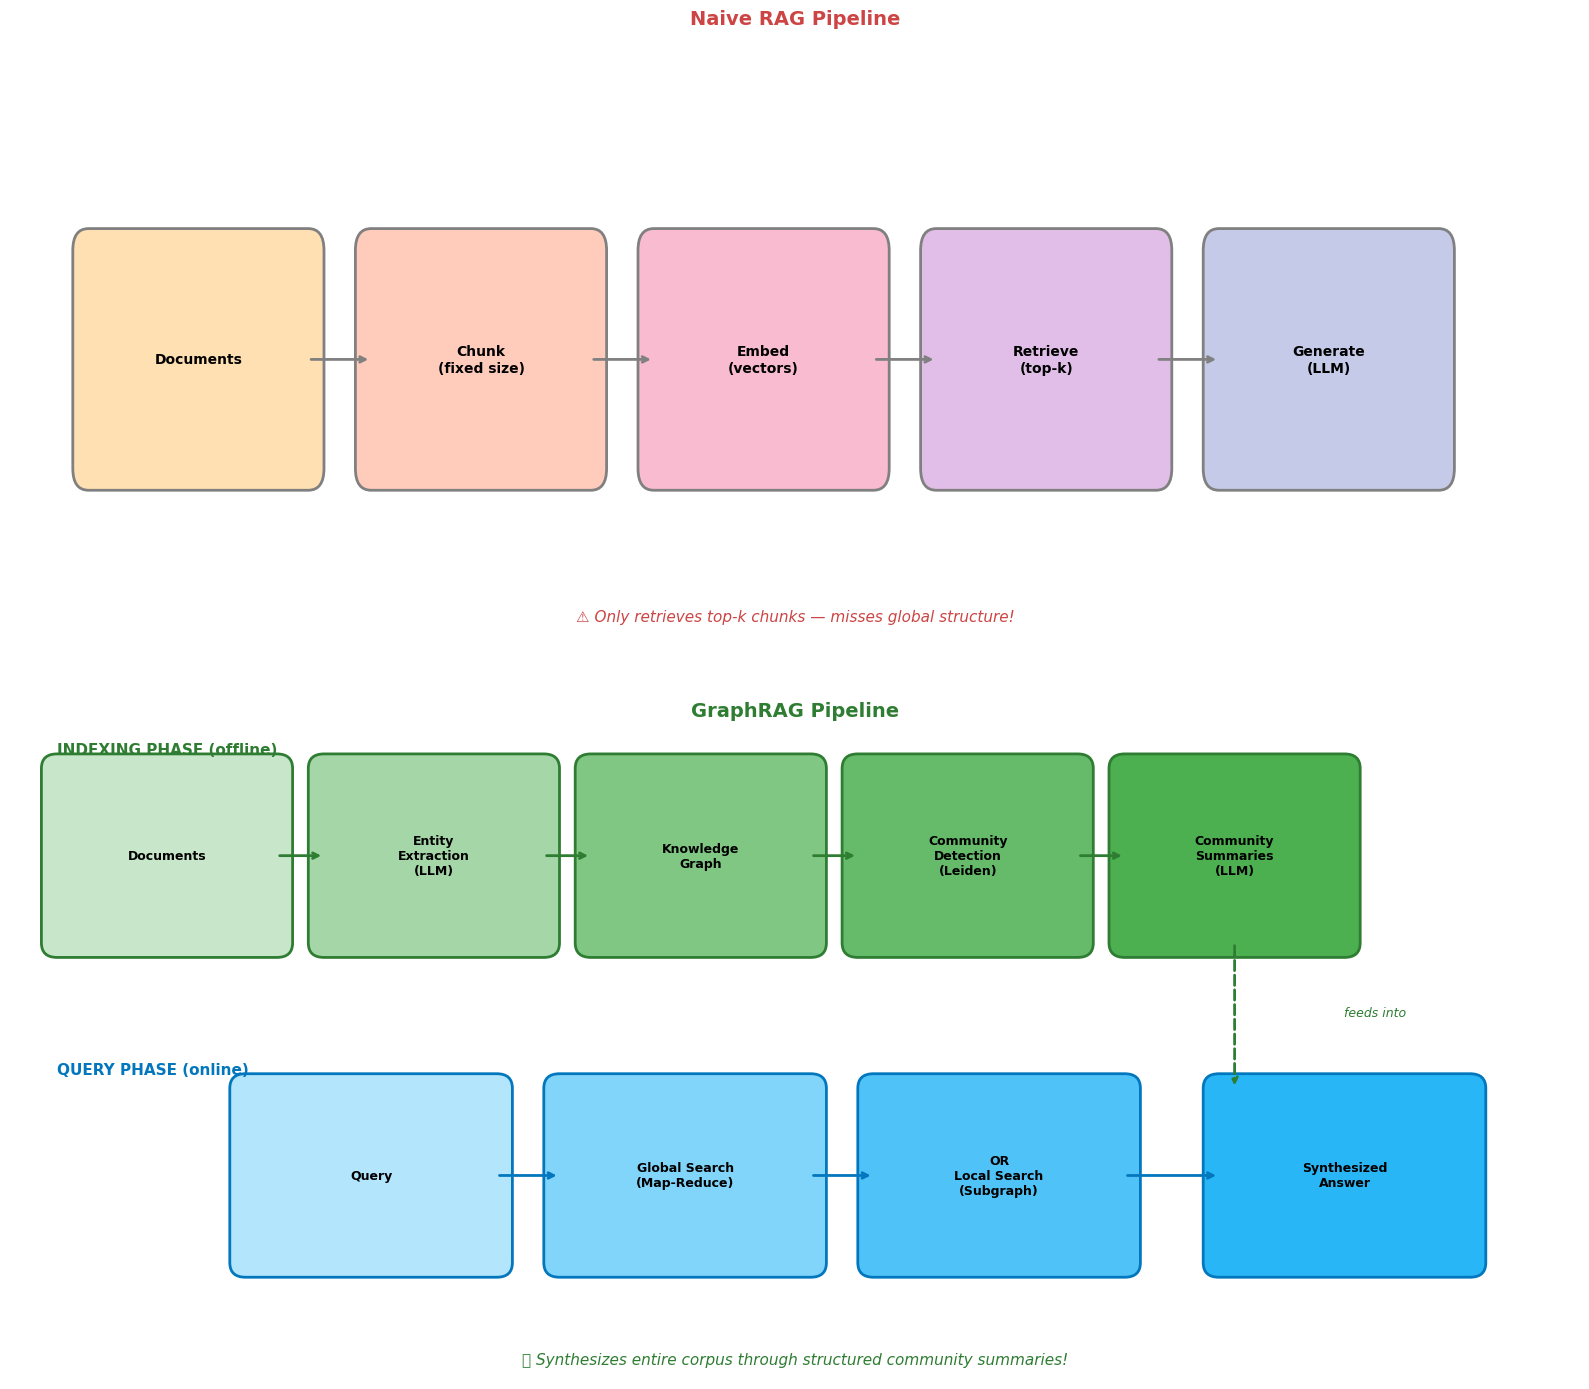


🌟 Summary: GraphRAG adds a graph-based intelligence layer between documents
   and the query engine, enabling answers that span the entire corpus.


In [0]:
# =============================================================================
# FINAL VISUALIZATION: GraphRAG vs Naive RAG Pipeline Comparison
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, axes = plt.subplots(2, 1, figsize=(16, 14))

# --- Naive RAG Pipeline ---
ax1 = axes[0]
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 3)
ax1.set_title("Naive RAG Pipeline", fontsize=14, fontweight='bold', color='#CC4444')
ax1.axis('off')

# Boxes for Naive RAG
naive_steps = [
    (0.5, 1.0, "Documents", "#FFE0B2"),
    (2.3, 1.0, "Chunk\n(fixed size)", "#FFCCBC"),
    (4.1, 1.0, "Embed\n(vectors)", "#F8BBD0"),
    (5.9, 1.0, "Retrieve\n(top-k)", "#E1BEE7"),
    (7.7, 1.0, "Generate\n(LLM)", "#C5CAE9"),
]

for x, y, text, color in naive_steps:
    box = FancyBboxPatch((x, y), 1.4, 1.0, boxstyle="round,pad=0.1", 
                         facecolor=color, edgecolor='gray', linewidth=2)
    ax1.add_patch(box)
    ax1.text(x + 0.7, y + 0.5, text, ha='center', va='center', fontsize=10, fontweight='bold')

# Arrows
for i in range(len(naive_steps) - 1):
    x1 = naive_steps[i][0] + 1.4
    x2 = naive_steps[i+1][0]
    ax1.annotate('', xy=(x2, 1.5), xytext=(x1, 1.5),
                arrowprops=dict(arrowstyle='->', color='gray', lw=2))

# Limitation callout
ax1.text(5.0, 0.3, "⚠️ Only retrieves top-k chunks — misses global structure!", 
         ha='center', fontsize=11, color='#CC4444', fontstyle='italic')

# --- GraphRAG Pipeline ---
ax2 = axes[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 4.5)
ax2.set_title("GraphRAG Pipeline", fontsize=14, fontweight='bold', color='#2E7D32')
ax2.axis('off')

# Indexing phase
index_steps = [
    (0.3, 3.0, "Documents", "#C8E6C9"),
    (2.0, 3.0, "Entity\nExtraction\n(LLM)", "#A5D6A7"),
    (3.7, 3.0, "Knowledge\nGraph", "#81C784"),
    (5.4, 3.0, "Community\nDetection\n(Leiden)", "#66BB6A"),
    (7.1, 3.0, "Community\nSummaries\n(LLM)", "#4CAF50"),
]

for x, y, text, color in index_steps:
    box = FancyBboxPatch((x, y), 1.4, 1.2, boxstyle="round,pad=0.1", 
                         facecolor=color, edgecolor='#2E7D32', linewidth=2)
    ax2.add_patch(box)
    ax2.text(x + 0.7, y + 0.6, text, ha='center', va='center', fontsize=9, fontweight='bold')

for i in range(len(index_steps) - 1):
    x1 = index_steps[i][0] + 1.4
    x2 = index_steps[i+1][0]
    ax2.annotate('', xy=(x2, 3.6), xytext=(x1, 3.6),
                arrowprops=dict(arrowstyle='->', color='#2E7D32', lw=2))

# Query phase
query_steps = [
    (1.5, 0.8, "Query", "#B3E5FC"),
    (3.5, 0.8, "Global Search\n(Map-Reduce)", "#81D4FA"),
    (5.5, 0.8, "OR\nLocal Search\n(Subgraph)", "#4FC3F7"),
    (7.7, 0.8, "Synthesized\nAnswer", "#29B6F6"),
]

for x, y, text, color in query_steps:
    box = FancyBboxPatch((x, y), 1.6, 1.2, boxstyle="round,pad=0.1", 
                         facecolor=color, edgecolor='#0277BD', linewidth=2)
    ax2.add_patch(box)
    ax2.text(x + 0.8, y + 0.6, text, ha='center', va='center', fontsize=9, fontweight='bold')

for i in range(len(query_steps) - 1):
    x1 = query_steps[i][0] + 1.6
    x2 = query_steps[i+1][0]
    ax2.annotate('', xy=(x2, 1.4), xytext=(x1, 1.4),
                arrowprops=dict(arrowstyle='->', color='#0277BD', lw=2))

# Connect indexing to query
ax2.annotate('', xy=(7.8, 2.0), xytext=(7.8, 3.0),
            arrowprops=dict(arrowstyle='->', color='#2E7D32', lw=2, linestyle='dashed'))
ax2.text(8.5, 2.5, "feeds into", fontsize=9, color='#2E7D32', fontstyle='italic')

# Labels
ax2.text(0.3, 4.3, "INDEXING PHASE (offline)", fontsize=11, fontweight='bold', color='#2E7D32')
ax2.text(0.3, 2.1, "QUERY PHASE (online)", fontsize=11, fontweight='bold', color='#0277BD')

# Success callout
ax2.text(5.0, 0.1, "✅ Synthesizes entire corpus through structured community summaries!", 
         ha='center', fontsize=11, color='#2E7D32', fontstyle='italic')

plt.tight_layout()
plt.savefig('/tmp/graphrag_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n🌟 Summary: GraphRAG adds a graph-based intelligence layer between documents")
print("   and the query engine, enabling answers that span the entire corpus.")

## Conclusion & Key Takeaways

### Summary

| Aspect | What We Learned |
| --- | --- |
| **Problem** | Naive RAG fails on global/synthesis questions because top-k retrieval is fundamentally local |
| **Solution** | GraphRAG builds a knowledge graph, detects communities, and pre-computes hierarchical summaries |
| **Mechanism** | Entity extraction → Graph construction → Community detection → Summary generation → Map-Reduce search |
| **Superiority** | Wins on global synthesis, relationship awareness, multi-hop reasoning, and completeness |
| **Trade-off** | Higher indexing cost (more LLM calls) in exchange for dramatically better answers on complex questions |

### Key References

1. **Original Paper**: "From Local to Global: A Graph RAG Approach to Query-Focused Summarization" (Edge et al., Microsoft Research, 2024)
2. **GitHub**: [microsoft/graphrag](https://github.com/microsoft/graphrag)
3. **Leiden Algorithm**: "From Louvain to Leiden: guaranteeing well-connected communities" (Traag et al., 2019)
4. **RAPTOR** (related work): "RAPTOR: Recursive Abstractive Processing for Tree-Organized Retrieval" (Sarthi et al., 2024)

### The Bottom Line

> **Naive RAG answers: "What does this passage say?"**
> 
> **GraphRAG answers: "What does the entire corpus mean?"**

For any application where users ask analytical, thematic, or relationship-based questions over large document collections, GraphRAG represents a paradigm shift from retrieval to **understanding**.